In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
project_root='/home/g202393750/Documents/Superresolution/The definitive model/'
sys.path.append(project_root)

import numpy as np
from Utils.utils_modif import *

test_data_base=f"{project_root}Data/Train/original/"

# Importation

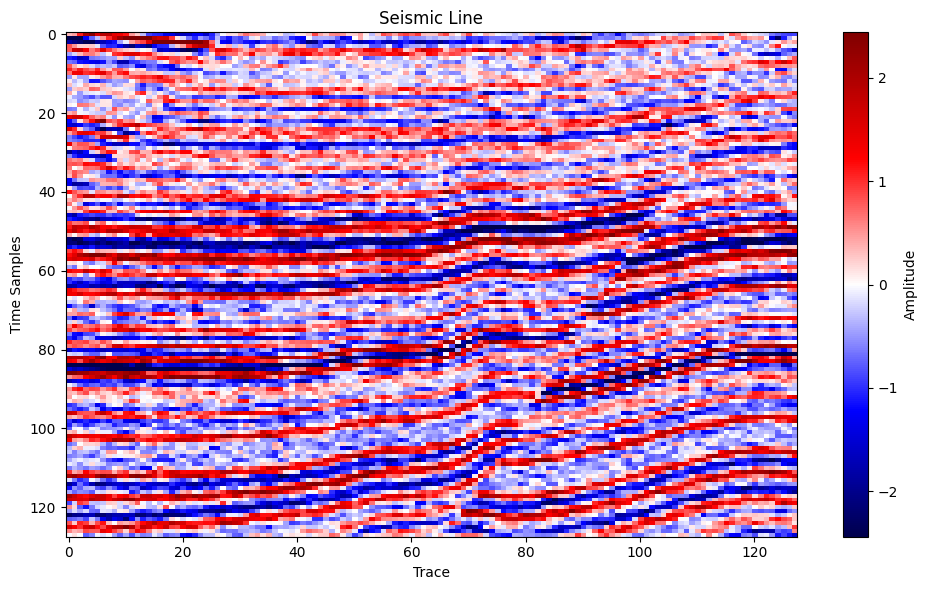

(128, 128)


In [2]:
test_data_path=f"{test_data_base}nx2.npy/3144.npy"
seismic_data_LR = np.load(test_data_path)
plot_2D_seismic(seismic_data_LR)
print(seismic_data_LR.shape)

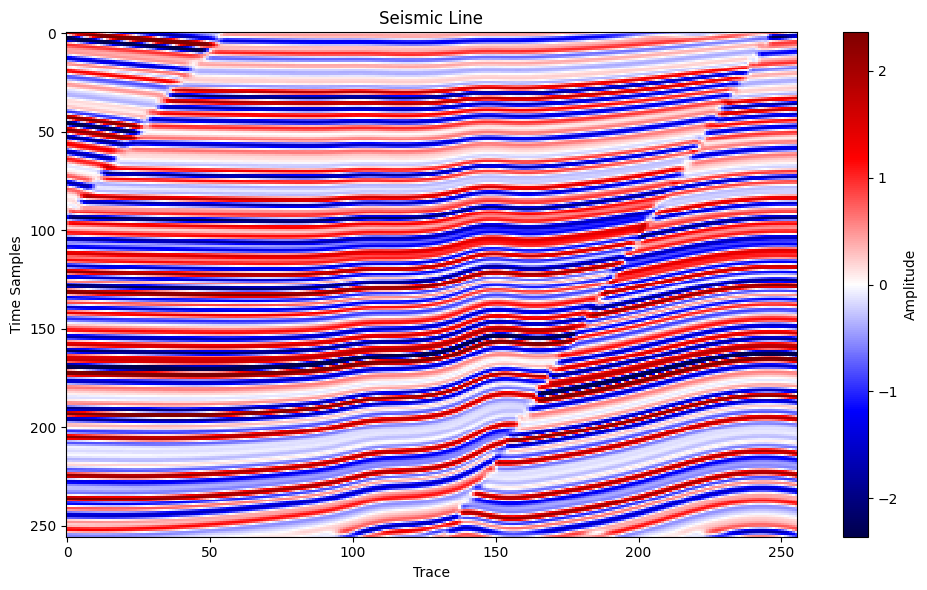

(256, 256)


In [3]:
test_data_path=f"{test_data_base}sx.npy/3144.npy"
seismic_data_HR = np.load(test_data_path)
plot_2D_seismic(seismic_data_HR)
print(seismic_data_HR.shape)

In [4]:
NOISE_LEVEL_HIGH = {
    "coherent_lowfreq_noise": {"amp": 0.20},
    "smooth_random_noise":    {"std": 0.50},
    "trace_gain_loss":        {"prob": 0.30, "gain_min": 0.30, "gain_max": 0.80},
    "localized_spike":        {"n_spikes": 10, "amp": 0.50},
    "mild_phase_shift":       {"max_phase_deg": 30}
}

def trace_dropout(x, drop_prob):
    """
    Drop entire seismic traces with probability drop_prob.

    x: array of shape (n_traces, n_samples)
    drop_prob: float between 0 and 1
    """
    mask = np.random.rand(x.shape[0]) > drop_prob
    return x * mask[:, np.newaxis]




In [5]:
Cond_high_noise = apply_noise(seismic_data_LR, NOISE_LEVEL_HIGH)
Cond_high = trace_dropout(Cond_high_noise, .6)

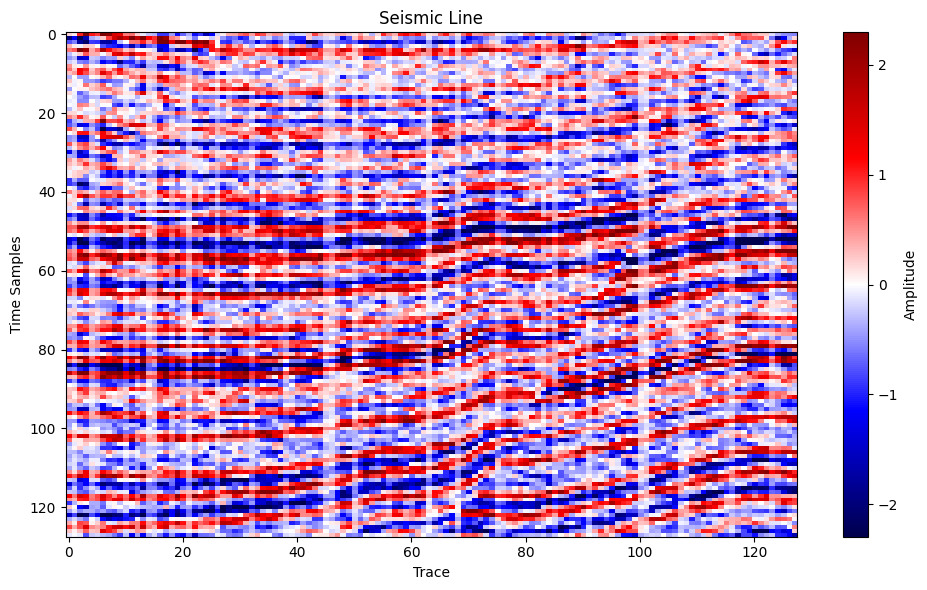

In [6]:
plot_2D_seismic(Cond_high_noise)

In [9]:
np.save(f"{project_root}Paper visualization/prediction/joint_task_severe/Cond.npy",
        Cond_high)

In [10]:
np.save(f"{project_root}Paper visualization/prediction/joint_task_severe/GroundTruth.npy",
        seismic_data_HR)